In [19]:
import pandas as pd
import numpy as np

In [2]:
df_raw = pd.read_csv(
    f"tsv/cells_properties/LUNG-NSCLC2-0558-FIXT-01-IF1-01_#_cells_properties_#_f9e776cbf3f124bd9a0d3af7ab4423ba.tsv.gz",
    sep="\t"
)

df_raw.head(10)

,cell.ID,nucleus.x,nucleus.y,CD15.score,CK.score,CD3.score,CD11c.score,CD20.score,CD163.score,CD15.score.normalized,CK.score.normalized,CD3.score.normalized,CD11c.score.normalized,CD20.score.normalized,CD163.score.normalized,tissue.type,phenotype,in.ROI.next_to_tumor_tissue,in.ROI.tumor_tissue
0,1,6441.5,37984.3,0.755990,0.557696,2.339746,0.258212,0.259974,1.439782,0.0391,0.0996,0.1665,0.0199,0.0582,0.0607,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True
1,2,6269.3,37743.1,0.836617,0.557638,3.188341,0.390046,0.181936,61.754458,0.0432,0.0996,0.2269,0.0300,0.0407,2.6035,stroma,CD15-CK-CD3-CD11c-CD20-CD163+,False,True
2,3,6454.4,37814.1,0.589492,0.557628,15.492811,0.320116,0.171355,2.378751,0.0305,0.0996,1.1027,0.0246,0.0383,0.1003,stroma,CD15-CK-CD3+CD11c-CD20-CD163-,False,True
3,4,6677.6,37760.0,41.572382,0.555882,2.700532,1.368053,0.172937,2.184452,2.1484,0.0993,0.1922,0.1052,0.0387,0.0921,stroma,CD15+CK-CD3-CD11c-CD20-CD163-,False,True
4,5,6853.3,37688.5,1.739946,2.323499,3.762925,1.219106,0.473835,18.794610,0.0899,0.4149,0.2678,0.0938,0.1060,0.7924,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True
5,6,6551.1,38009.1,6.076008,1.391599,3.291529,0.496726,0.338300,2.183685,0.3140,0.2485,0.2343,0.0382,0.0757,0.0921,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True
6,7,6446.4,37855.3,0.969636,0.826132,2.830220,0.512788,0.367790,29.141773,0.0501,0.1475,0.2014,0.0394,0.0823,1.2286,stroma,CD15-CK-CD3-CD11c-CD20-CD163+,False,True
7,8,6874.1,37723.3,0.745601,0.555271,2.425906,0.384616,0.166430,2.802524,0.0385,0.0991,0.1727,0.0296,0.0372,0.1182,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True
8,9,6751.6,37831.4,1.196992,2.220264,48.413717,0.694293,0.422202,3.865745,0.0619,0.3964,3.4458,0.0534,0.0945,0.1630,stroma,CD15-CK-CD3+CD11c-CD20-CD163-,False,True
9,10,6690.5,37707.4,1.065338,0.829584,4.011298,0.894939,6.038223,7.446413,0.0551,0.1481,0.2855,0.0688,1.3508,0.3139,stroma,CD15-CK-CD3-CD11c-CD20+CD163-,False,True


# Viewing CK

In [13]:
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

In [24]:
def plot_hist_column(ax: Axes, column: pd.Series, column_name: str|None = None) -> None:
    ax.hist(column, rwidth=0.8, bins = 100)

    if column_name is not None:
        ax.set_title(f"{column_name} hist")

    ax.set_xlabel(f"value")
    ax.set_ylabel(f"count")

    ax.grid(True, ls = "--")

    ax.axvline(column.mean(), label = f"mean", color = "red", lw = 1, ls = "--")
    ax.axvline(column.median(), label = f"median", color = "green", lw = 1, ls = "--")


    ax.legend()

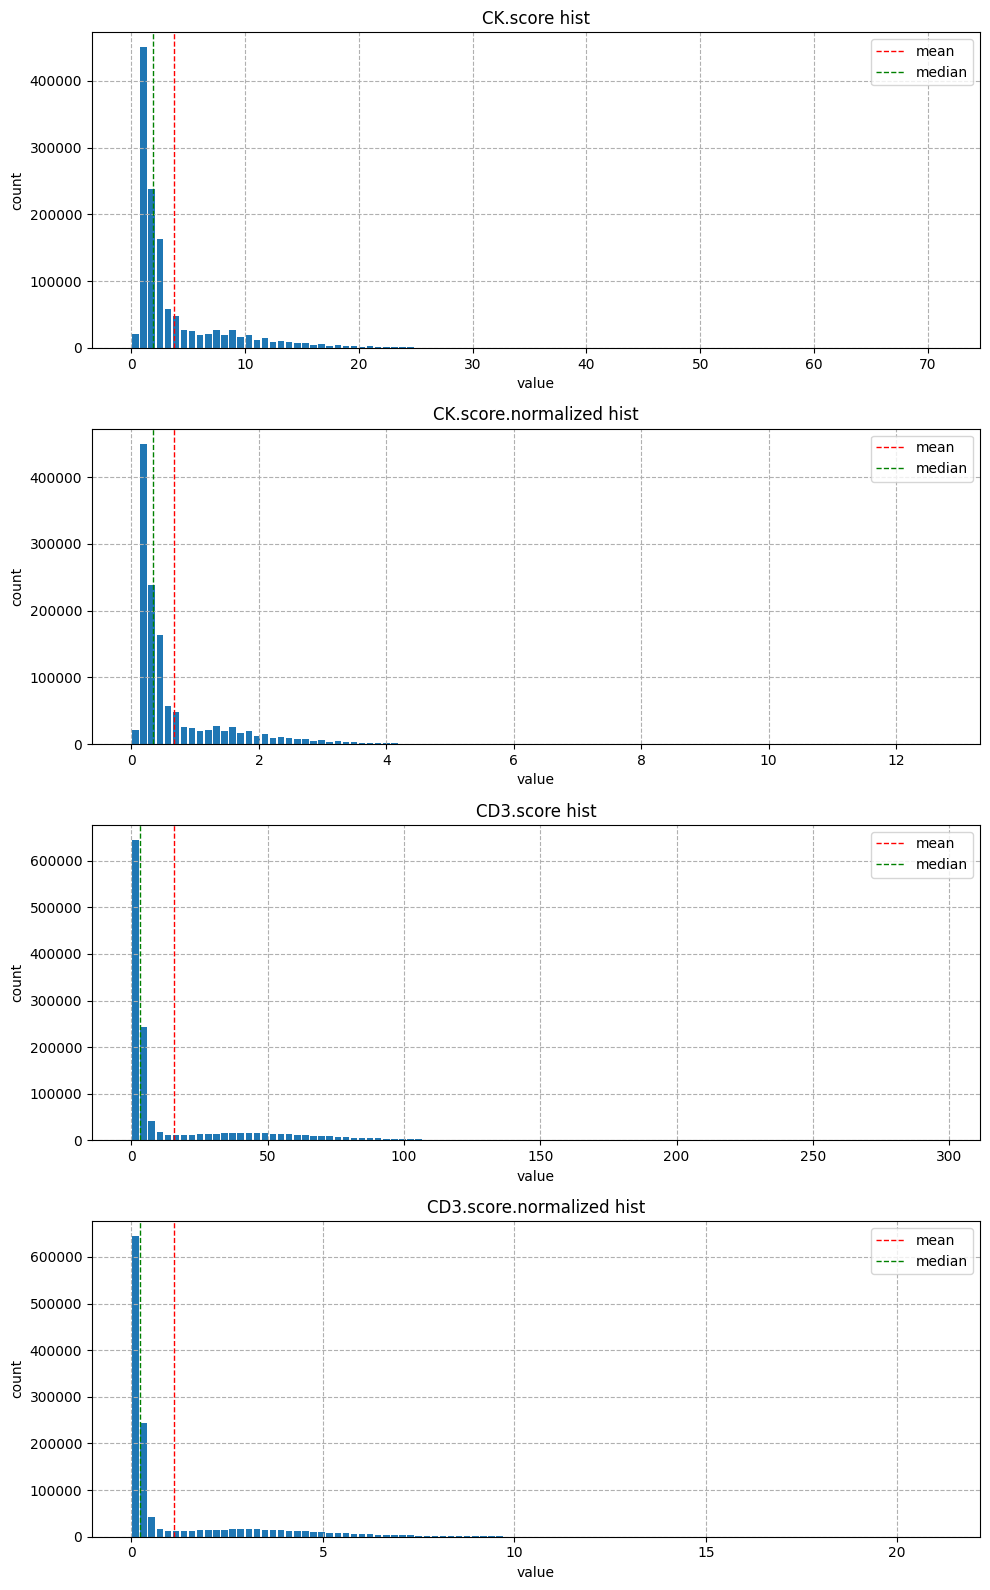

In [25]:
cols_to_plot = ["CK.score", "CK.score.normalized", "CD3.score", "CD3.score.normalized"]

fig, axs = plt.subplots(len(cols_to_plot), figsize = (10, 4 * len(cols_to_plot)))

for i, col in enumerate(cols_to_plot):
    plot_hist_column(axs[i], df_raw[col], column_name=col)

fig.tight_layout()

# T-Test

In [28]:
from scipy.stats import ttest_ind, shapiro

In [29]:
ttest_ind(df_raw[df_raw["tissue.type"]=="tumor"]["CK.score.normalized"], df_raw[df_raw["tissue.type"]!="tumor"]["CK.score.normalized"])

TtestResult(statistic=np.float64(1325.2003026312484), pvalue=np.float64(0.0), df=np.float64(1291512.0))

In [30]:
shapiro(df_raw[df_raw["tissue.type"]=="tumor"]["CK.score.normalized"]), shapiro(df_raw[df_raw["tissue.type"]!="tumor"]["CK.score.normalized"])

/home/kchadzynski/Pulpit/mimuw/BiologiaSystemów/CW5-B_hackathon/SysBiolHackaton/venv/lib64/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 248932.
  res = hypotest_fun_out(*samples, **kwds)
/home/kchadzynski/Pulpit/mimuw/BiologiaSystemów/CW5-B_hackathon/SysBiolHackaton/venv/lib64/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 1042582.
  res = hypotest_fun_out(*samples, **kwds)


(ShapiroResult(statistic=np.float64(0.9324466071676425), pvalue=np.float64(8.01850935168039e-120)),
 ShapiroResult(statistic=np.float64(0.477047922914022), pvalue=np.float64(1.36602291807275e-213)))

# Log1p Trnasform

In [35]:
df_log1p_sel_cols = df_raw[cols_to_plot]

for col in cols_to_plot:
    df_log1p_sel_cols[col] = np.log1p(df_log1p_sel_cols[col])

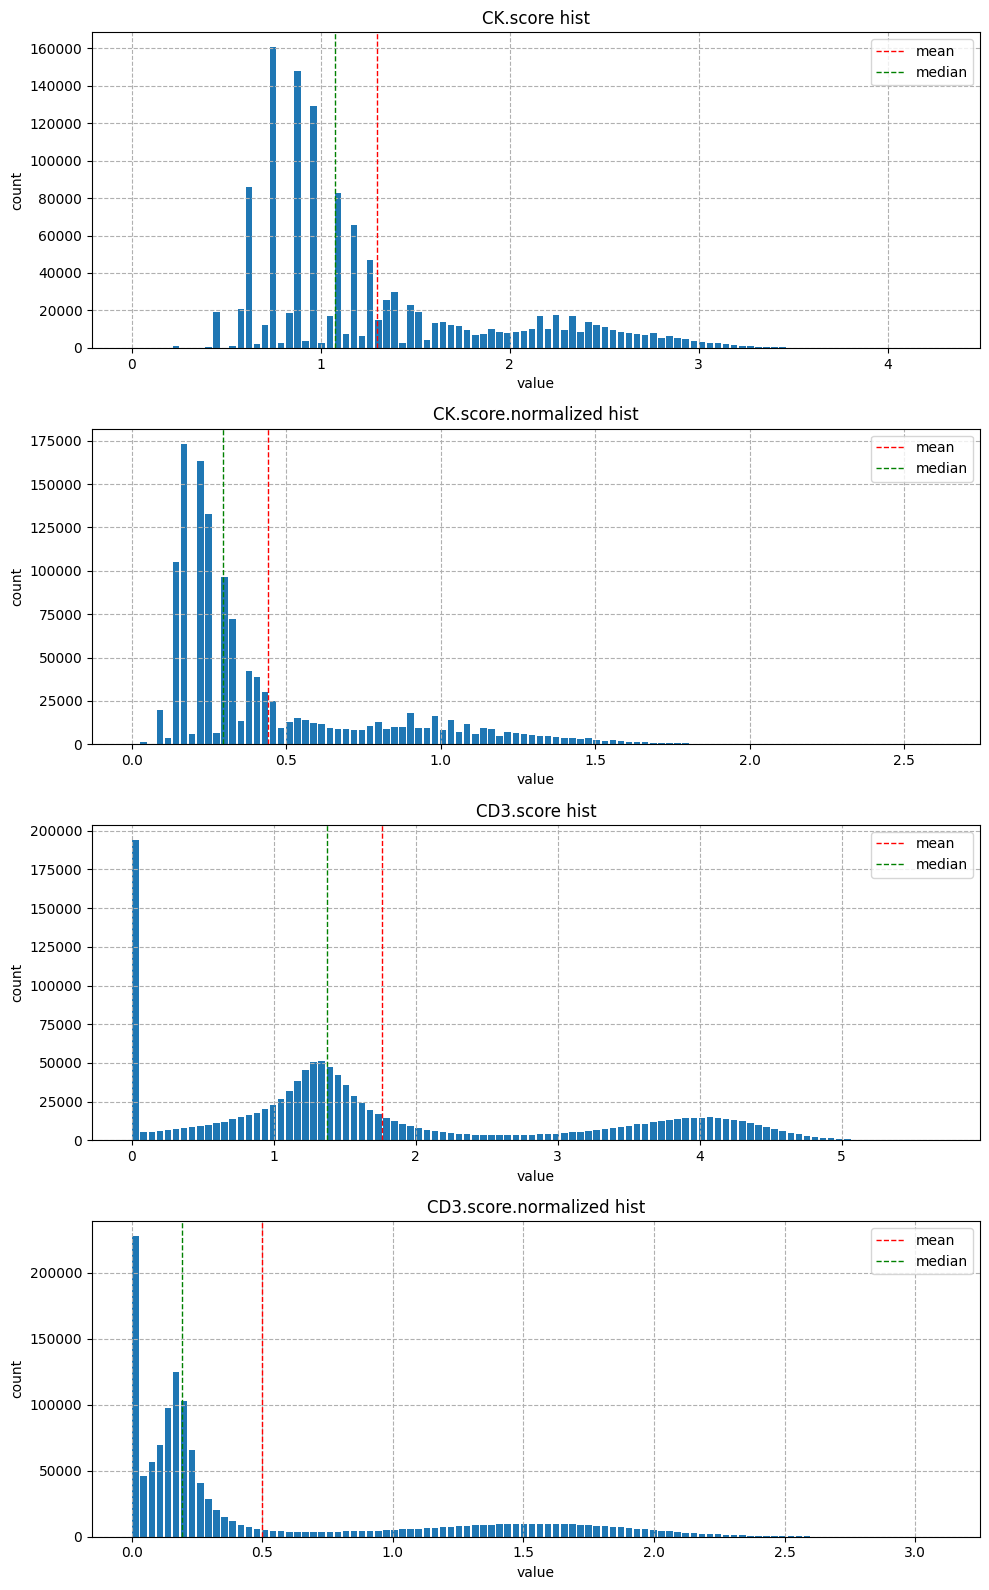

In [36]:
cols_to_plot = ["CK.score", "CK.score.normalized", "CD3.score", "CD3.score.normalized"]

fig, axs = plt.subplots(len(cols_to_plot), figsize = (10, 4 * len(cols_to_plot)))

for i, col in enumerate(cols_to_plot):
    plot_hist_column(axs[i], df_log1p_sel_cols[col], column_name=col)

fig.tight_layout()

In [38]:
df_log1p_sel_cols[cols_to_plot].describe()

,CK.score,CK.score.normalized,CD3.score,CD3.score.normalized
count,1.291514e+06,1.291514e+06,1.291514e+06,1.291514e+06
mean,1.298135e+00,4.407742e-01,1.765358e+00,5.011264e-01
std,6.570997e-01,3.506355e-01,1.403590e+00,6.312488e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.547116e-01,2.160787e-01,8.350614e-01,8.883471e-02
50%,1.075827e+00,2.963940e-01,1.379574e+00,1.919418e-01
75%,1.635395e+00,5.525624e-01,2.894910e+00,7.956135e-01
max,4.278264e+00,2.617257e+00,5.696596e+00,3.096857e+00


# Adding CellType

In [ ]:
cell_types = pd.read_csv(f"tsv/IF1_phen_to_cell_mapping.csv")

cell_types

,celltype
phenotype,
CD11c-CD15-CD163-CD20-CD3-CK+,CD15-Tumor
CD11c-CD15-CD163-CD20-CD3-CK-,other
CD11c-CD15-CD163-CD20-CD3+CK-,Tcell
CD11c-CD15-CD163+CD20-CD3-CK-,Macrophage
CD11c+CD15-CD163+CD20-CD3-CK-,Macrophage
...,...
CD11c+CD15+CD163+CD20+CD3+CK-,BnTcell
CD11c+CD15+CD163-CD20+CD3-CK-,Bcell
CD11c+CD15+CD163+CD20+CD3-CK+,Bcell


In [50]:
phenotype_to_cell_type: dict[frozenset[str], str] = {frozenset(phenotype.replace("C", " C").split(" ")): cell_type 
                                               for phenotype, cell_type in cell_types["celltype"].to_dict().items()}

phenotype_to_cell_type

{frozenset({'',
            'CD11c-',
            'CD15-',
            'CD163-',
            'CD20-',
            'CD3-',
            'CK+'}): 'CD15-Tumor',
 frozenset({'', 'CD11c-', 'CD15-', 'CD163-', 'CD20-', 'CD3-', 'CK-'}): 'other',
 frozenset({'', 'CD11c-', 'CD15-', 'CD163-', 'CD20-', 'CD3+', 'CK-'}): 'Tcell',
 frozenset({'',
            'CD11c-',
            'CD15-',
            'CD163+',
            'CD20-',
            'CD3-',
            'CK-'}): 'Macrophage',
 frozenset({'',
            'CD11c+',
            'CD15-',
            'CD163+',
            'CD20-',
            'CD3-',
            'CK-'}): 'Macrophage',
 frozenset({'', 'CD11c-', 'CD15-', 'CD163+', 'CD20-', 'CD3+', 'CK-'}): 'Tcell',
 frozenset({'',
            'CD11c+',
            'CD15-',
            'CD163+',
            'CD20+',
            'CD3+',
            'CK-'}): 'BnTcell',
 frozenset({'', 'CD11c+', 'CD15-', 'CD163+', 'CD20-', 'CD3+', 'CK-'}): 'Tcell',
 frozenset({'',
            'CD11c+',
            'CD15

In [53]:
df_raw["cell_type"] = [
    phenotype_to_cell_type[frozenset(df_raw.iloc[i]["phenotype"].replace("C", " C").split(" "))] for i in df_raw.index.unique()
]

In [54]:
df_raw

,cell.ID,nucleus.x,nucleus.y,CD15.score,CK.score,CD3.score,CD11c.score,CD20.score,CD163.score,CD15.score.normalized,CK.score.normalized,CD3.score.normalized,CD11c.score.normalized,CD20.score.normalized,CD163.score.normalized,tissue.type,phenotype,in.ROI.next_to_tumor_tissue,in.ROI.tumor_tissue,cell_type
0,1,6441.5,37984.3,0.755990,0.557696,2.339746,0.258212,0.259974,1.439782,0.0391,0.0996,0.1665,0.0199,0.0582,0.0607,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,other
1,2,6269.3,37743.1,0.836617,0.557638,3.188341,0.390046,0.181936,61.754458,0.0432,0.0996,0.2269,0.0300,0.0407,2.6035,stroma,CD15-CK-CD3-CD11c-CD20-CD163+,False,True,Macrophage
2,3,6454.4,37814.1,0.589492,0.557628,15.492811,0.320116,0.171355,2.378751,0.0305,0.0996,1.1027,0.0246,0.0383,0.1003,stroma,CD15-CK-CD3+CD11c-CD20-CD163-,False,True,Tcell
3,4,6677.6,37760.0,41.572382,0.555882,2.700532,1.368053,0.172937,2.184452,2.1484,0.0993,0.1922,0.1052,0.0387,0.0921,stroma,CD15+CK-CD3-CD11c-CD20-CD163-,False,True,Neutrophil
4,5,6853.3,37688.5,1.739946,2.323499,3.762925,1.219106,0.473835,18.794610,0.0899,0.4149,0.2678,0.0938,0.1060,0.7924,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291509,1293254,11668.1,37127.9,0.885415,1.383441,8.514799,0.495982,0.155242,3.286529,0.0458,0.2470,0.6060,0.0382,0.0347,0.1386,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,other
1291510,1293255,11538.1,37146.7,1.478724,1.380297,0.340273,1.202922,0.705136,87.193845,0.0764,0.2465,0.0242,0.0925,0.1577,3.6760,stroma,CD15-CK-CD3-CD11c-CD20-CD163+,False,True,Macrophage
1291511,1293256,11543.5,36877.8,1.035241,1.032667,1.865445,0.370813,0.146313,4.602898,0.0535,0.1844,0.1328,0.0285,0.0327,0.1941,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,other
1291512,1293257,11178.9,37007.3,1.251715,12.831778,0.533214,0.712859,0.662112,3.249969,0.0647,2.2912,0.0380,0.0548,0.1481,0.1370,tumor,CD15-CK+CD3-CD11c-CD20-CD163-,False,True,CD15-Tumor
